# Model Definition and Evaluation
## Table of Contents
1. [Model Selection](#model-selection)
2. [Feature Engineering](#feature-engineering)
3. [Hyperparameter Tuning](#hyperparameter-tuning)
4. [Implementation](#implementation)
5. [Evaluation Metrics](#evaluation-metrics)
6. [Comparative Analysis](#comparative-analysis)


In [56]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
# Import models you're considering
from sklearn.linear_model import ElasticNetCV
from sklearn.ensemble import GradientBoostingRegressor

## Model Selection

[Discuss the type(s) of models you consider for this task, and justify the selection.]



#### Feature Engineering
The merging of groups like:

df['body_mind']=df['mental_health_score'] + df['baseline_cognitive_score']

df['family']=df['socioeconomic_status'] 

df['support']=df['social_support_enhancement'] + df['school_quality_score']

causes worse results. The features doesn't seem to be affected in the same way then the others, who are grouped together by content, but obvious not in effect

#### and about hyperparameter tuning:
the model is already tuned by CV variaion of Elastic Net: automatic optimization of alpha and l1-ratio. so manual tuning wont't and didn't changed the outcome.



In [15]:
# Load the dataset
df = pd.read_csv('/Users/libraryfree/Desktop/MachineLearning/CausalInf_project/sequential_mediation_dataset.csv')

# Perform any feature engineering steps

# Feature and target variable selection
x = df[['educational_intervention','social_support_enhancement', 'mental_health_score', 'socioeconomic_status', 'school_quality_score', 'baseline_cognitive_score', 'random_noise']]
y = df['coping_strategy_improvement']

# Split the dataset
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#models
model_base=ElasticNetCV()
model_base.fit(x_train, y_train)

model_train=GradientBoostingRegressor()
model_train.fit(x_train, y_train)
#Predictions
y_pred_base=model_base.predict(x_test)
y_pred_train=model_train.predict(x_test)


## Evaluation Metrics

[Clearly specify which metrics you'll use to evaluate the model performance, and why you've chosen these metrics.]


In [27]:
# Evaluate the model using your chosen metrics
#Evaluations
print('Evaluation of the Models\n')
print('Baseline Model: ElasticNetCV')
r2_base=r2_score(y_test, y_pred_base) #coefficient of determination: Verhältnis der Variation im target zu 'unabhängingen' Verursacher-Variablen
mse_base=mean_squared_error(y_test, y_pred_base) #durchscnittlicher fehler
mae_base = mean_absolute_error(y_test, y_pred_base) #average absolute difference between calculated and real value
rmse_base = np.sqrt(mse_base) #in original units of target, same as mse
print(f'R²: {r2_base:.3f} \nMean squared error:\t {mse_base:.3f} \nMean absolute error:\t {mae_base:.3f} \nroot mean squared error: {rmse_base:.3f}')
print(f'Level of regularization: {model_base.alpha_:.3f}')
print(f'Mix of Lasso and Ridge:\t {model_base.l1_ratio_}')
print(f'Weights: {model_base.coef_}')
print(f'Bias: {model_base.intercept_}')

print('\n\nTrainings Model: GradientBoostingRegressor')
r2_train=r2_score(y_test, y_pred_train) #coefficient of determination: Verhältnis der Variation im target zu 'unabhängingen' Verursacher-Variablen
mse_train=mean_squared_error(y_test, y_pred_train) #durchscnittlicher fehler
mae_train = mean_absolute_error(y_test, y_pred_train) #average absolute difference between calculated and real value
rmse_train = np.sqrt(mse_train)
print(f'R²: {r2_train:.3f} \nMean squared error:\t {mse_train:.3f} \nMean absolute error:\t {mae_train:.3f} \nroot mean squared error: {rmse_train:.3f}')


Evaluation of the Models

Baseline Model: ElasticNetCV
R²: 0.837 
Mean squared error:	 0.569 
Mean absolute error:	 0.587 
root mean squared error: 0.754
Level of regularization: 0.068
Mix of Lasso and Ridge:	 0.5
Weights: [ 0.15726815  0.27974348  0.06962821 -0.08039489  0.00158684 -0.07095698
  0.        ]
Bias: 0.35938667022077997


Trainings Model: GradientBoostingRegressor
R²: 0.805 
Mean squared error:	 0.681 
Mean absolute error:	 0.659 
root mean squared error: 0.825


## Comparative Analysis

[Compare the performance of your model(s) against the baseline model. Discuss any improvements or setbacks and the reasons behind them.]


In [ ]:
# Comparative Analysis code (if applicable)
# Example: comparing accuracy of the baseline model and the new model
# print(f"Baseline Model Accuracy: {baseline_accuracy}, New Model Accuracy: {new_model_accuracy}")

Feauture Cofficients in numbers:
socioeconomic_status         -0.080395
baseline_cognitive_score     -0.070957
random_noise                  0.000000
school_quality_score          0.001587
mental_health_score           0.069628
educational_intervention      0.157268
social_support_enhancement    0.279743

chosen alpha:    0.068
chosen l1_ratio: 0.500



Feature Importance in numbers:
random_noise                  0.010730
educational_intervention      0.017064
socioeconomic_status          0.018328
school_quality_score          0.026438
baseline_cognitive_score      0.029407
mental_health_score           0.076399
social_support_enhancement    0.821635


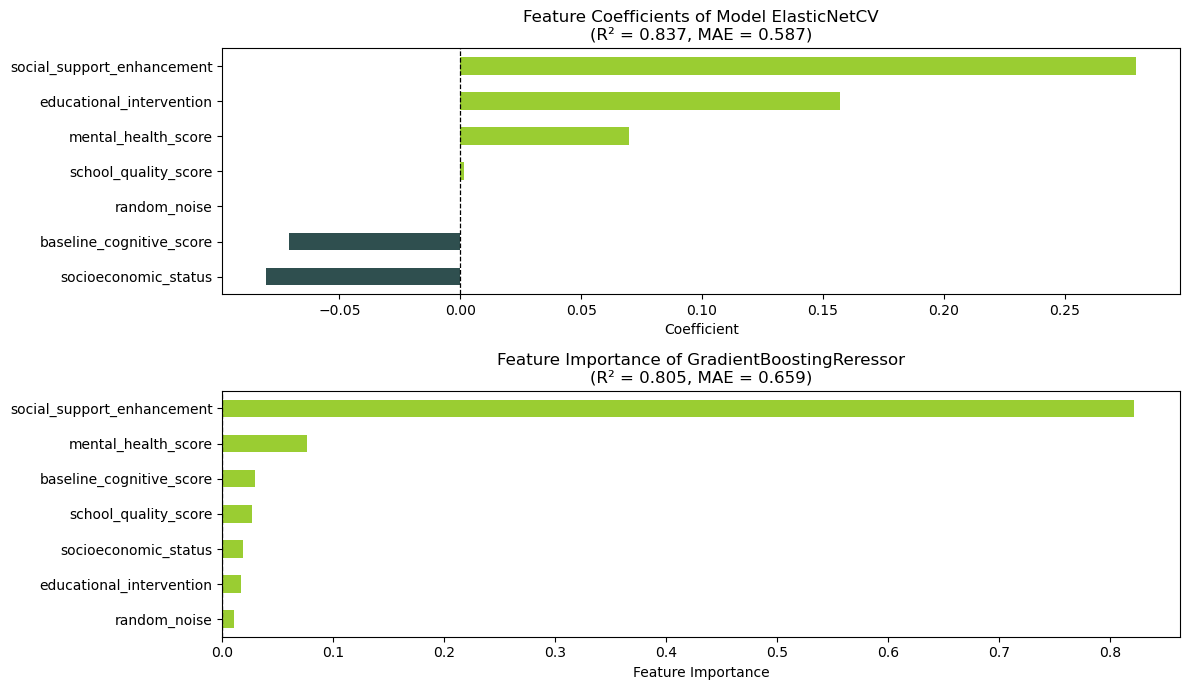

In [55]:
#check influence of features on coping enhancement for both mdoels
# Plot
fig, ax = plt.subplots(2,1, figsize=(12,7))

#model_base
coefs = pd.Series(model_base.coef_, index=x.columns).sort_values() #coefficients as series, to order coeffs to features
colors = ['darkslategrey' if c < 0 else 'yellowgreen' for c in coefs]
coefs.plot(kind='barh', ax=ax[0], color=colors)
ax[0].axvline(0, color='black', linewidth=0.9, linestyle='--')
ax[0].set_title(f'Feature Coefficients of Model ElasticNetCV\n(R² = {r2_base:.3f}, MAE = {mae_base:.3f})', fontsize=12)
ax[0].set_xlabel('Coefficient')

#GradientBoosting
feat_imp=pd.Series(model_train.feature_importances_, index=x.columns).sort_values()
colors = ['darkslategrey' if f < 0 else 'yellowgreen' for f in feat_imp]
feat_imp.plot(kind='barh', ax=ax[1], color=colors)

ax[1].axvline(0, color='black', linewidth=0.9, linestyle='--')
ax[1].set_title(f'Feature Importance of GradientBoostingReressor\n(R² = {r2_train:.3f}, MAE = {mae_train:.3f})', fontsize=12)
ax[1].set_xlabel('Feature Importance')

plt.tight_layout()
#plt.show()
plt.savefig('/Users/libraryfree/Desktop/MachineLearning/CausalInf_project/Feature_Importance.jpeg')

# Zahlen dazu
print(f'Feauture Cofficients in numbers:\n{coefs.to_string()}')
print(f"\nchosen alpha:    {model_base.alpha_:.3f}")
print(f"chosen l1_ratio: {model_base.l1_ratio_:.3f}")

print(f'\n\n\nFeature Importance in numbers:\n{feat_imp.to_string()}')



In [ ]:
#test trained model
